## REPORT ML PROJECT

In [1]:
import pandas as pd
import numpy as np
import optuna
import xgboost as xgb
from catboost import CatBoostRegressor 
import lightgbm as lgb
import pickle
import warnings
import os
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta, date
warnings.filterwarnings('ignore')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Exploratory Data Analysis

- The datasets describe historical raw material deliveries ("receivals") to Hydro.  
- Each delivery is linked to a purchase order (purchase_order_id) and a raw material (rm_id).  
- Deliveries occur over time, often in multiple batches per order.  
- The goal is to predict how much (weight in kg) will be received between **January 1, 2025**, and a chosen end date.  

Variables that may influence delivery rate:
- **Season:** some suppliers ship less frequently during winter months.  
- **Supplier:** some are more reliable than others.  
- **Order history:** larger orders often lead to more regular deliveries.  
- **Transportation:** long transit times can cause delays.  
- **Day of week:** There are no deliveries during the weekends.

In [2]:
purchase_orders = pd.read_csv("data/kernel/purchase_orders.csv")
receivals = pd.read_csv("data/kernel/receivals.csv")

#### How does the data look?

In [3]:
print(f'The shape of receivals is {receivals.shape}, and the shape of purchase orders is {purchase_orders.shape}')
print('For receivals we have the columns: ', receivals.columns)
print('For purchase orders we have the columns',  purchase_orders.columns)


The shape of receivals is (122590, 10), and the shape of purchase orders is (33171, 12)
For receivals we have the columns:  Index(['rm_id', 'product_id', 'purchase_order_id', 'purchase_order_item_no',
       'receival_item_no', 'batch_id', 'date_arrival', 'receival_status',
       'net_weight', 'supplier_id'],
      dtype='object')
For purchase orders we have the columns Index(['purchase_order_id', 'purchase_order_item_no', 'quantity',
       'delivery_date', 'product_id', 'product_version', 'created_date_time',
       'modified_date_time', 'unit_id', 'unit', 'status_id', 'status'],
      dtype='object')


#### Missing and inconsistent data:

In [4]:
receivals['date_arrival'] = pd.to_datetime(receivals['date_arrival'], utc=True)
receivals['date'] = receivals['date_arrival'].dt.date  # removes time of day
receivals['year'] = receivals['date_arrival'].dt.year.astype(int)
receivals['doy'] = receivals['date_arrival'].dt.day_of_year.astype(int)
receivals['month'] = receivals['date_arrival'].dt.month.astype(int)
receivals['day_of_week'] = receivals['date_arrival'].dt.day_of_week.astype(int)




missing_summary = (
    receivals.isna()
    .sum()
    .to_frame(name='missing_count')
    .assign(
        missing_percent=lambda x: 100 * x['missing_count'] / len(receivals)
    )
    .sort_values('missing_percent', ascending=False)
)

print(missing_summary)

                        missing_count  missing_percent
batch_id                        57825        47.169427
net_weight                         68         0.055469
product_id                         57         0.046496
rm_id                              57         0.046496
purchase_order_id                  53         0.043234
purchase_order_item_no             53         0.043234
receival_item_no                    0         0.000000
date_arrival                        0         0.000000
receival_status                     0         0.000000
supplier_id                         0         0.000000
date                                0         0.000000
year                                0         0.000000
doy                                 0         0.000000
month                               0         0.000000
day_of_week                         0         0.000000


57825


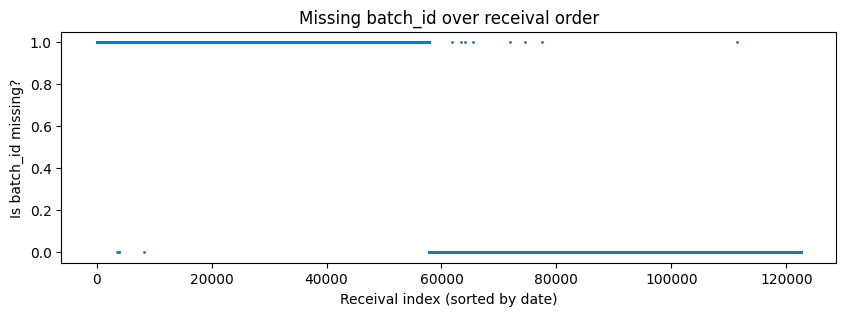

In [5]:
print(receivals['batch_id'].isna().sum())

plt.figure(figsize=(10,3))
plt.scatter(range(len(receivals["batch_id"])), receivals['batch_id'].isna(), s=1)
plt.title("Missing batch_id over receival order")
plt.xlabel("Receival index (sorted by date)")
plt.ylabel("Is batch_id missing?")
plt.show()

Batch id is only used in more recent years

In [6]:
# Create a summary table of missing counts and percentages
missing_summary = (
    purchase_orders.isna()
    .sum()
    .to_frame(name='missing_count')
    .assign(
        missing_percent=lambda x: 100 * x['missing_count'] / len(purchase_orders)
    )
    .sort_values('missing_percent', ascending=False)
)

print(missing_summary)

print((purchase_orders['unit'].isna() & purchase_orders['unit_id'].isna()).sum()) # 100% overlappping missing values



                        missing_count  missing_percent
modified_date_time                492         1.483223
unit_id                            44         0.132646
unit                               44         0.132646
purchase_order_id                   0         0.000000
delivery_date                       0         0.000000
quantity                            0         0.000000
purchase_order_item_no              0         0.000000
product_id                          0         0.000000
created_date_time                   0         0.000000
product_version                     0         0.000000
status_id                           0         0.000000
status                              0         0.000000
44


In [7]:
print(f"Status list = {purchase_orders['status'].value_counts()}")

Status list = status
Closed     28780
Deleted     3191
Open        1200
Name: count, dtype: int64


How does deleted effect?

In [8]:
print(purchase_orders["unit"].value_counts())

print(f"Percentage of units in kg: {100 * purchase_orders['unit'].value_counts().get('KG', 0) / len(purchase_orders):.2f}%")

unit
KG      33120
PUND        7
Name: count, dtype: int64
Percentage of units in kg: 99.85%


#### How many rm_ids are still active last 4 and 2 years?

In [9]:

receivals['date_arrival'] = pd.to_datetime(receivals['date_arrival'], utc=True)
receivals['date_arrival'] = receivals['date_arrival'].dt.tz_convert('Europe/Oslo')
receivals['date'] = pd.to_datetime(receivals['date_arrival'].dt.date)
receivals['year'] = receivals['date_arrival'].dt.year.astype(int)
# Filter to the last 4 years of the dataset:
cutoff_date_4y = receivals["date_arrival"].max() - pd.DateOffset(years=4)
cutoff_date_2y = receivals["date_arrival"].max() - pd.DateOffset(years=2)

recent_receivals_4y = receivals[receivals["date_arrival"] >= cutoff_date_4y]
recent_receivals_2y = receivals[receivals["date_arrival"] >= cutoff_date_2y]

unique_rm_ids_4y = recent_receivals_4y["rm_id"].nunique()
unique_rm_ids_2y = recent_receivals_2y["rm_id"].nunique()


print("Number of unique rm_ids last 4 years:", unique_rm_ids_4y)
print("Number of unique rm_ids last 2 years:", unique_rm_ids_2y)

Number of unique rm_ids last 4 years: 87
Number of unique rm_ids last 2 years: 72


#### How much is delivered each year and month?

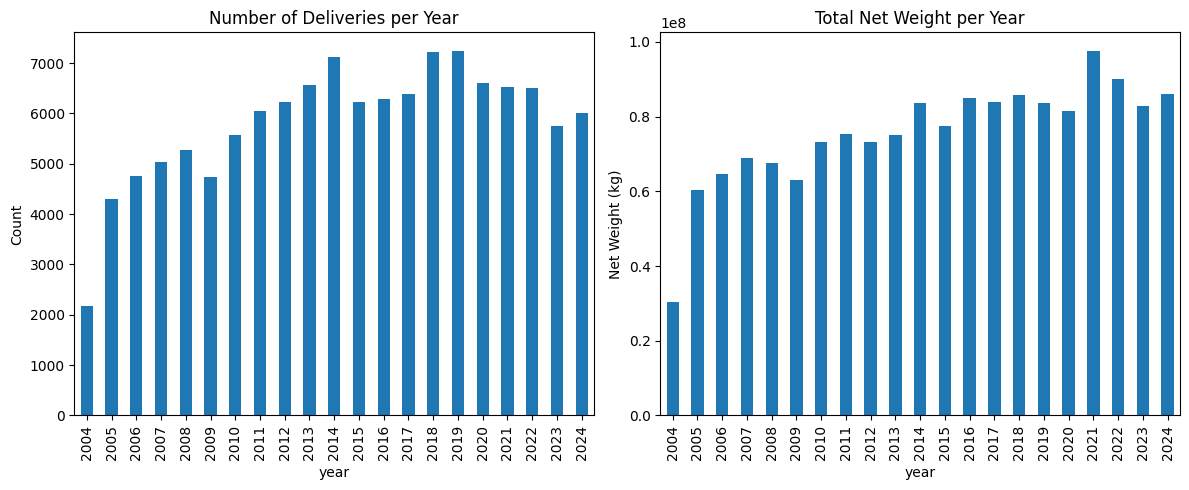

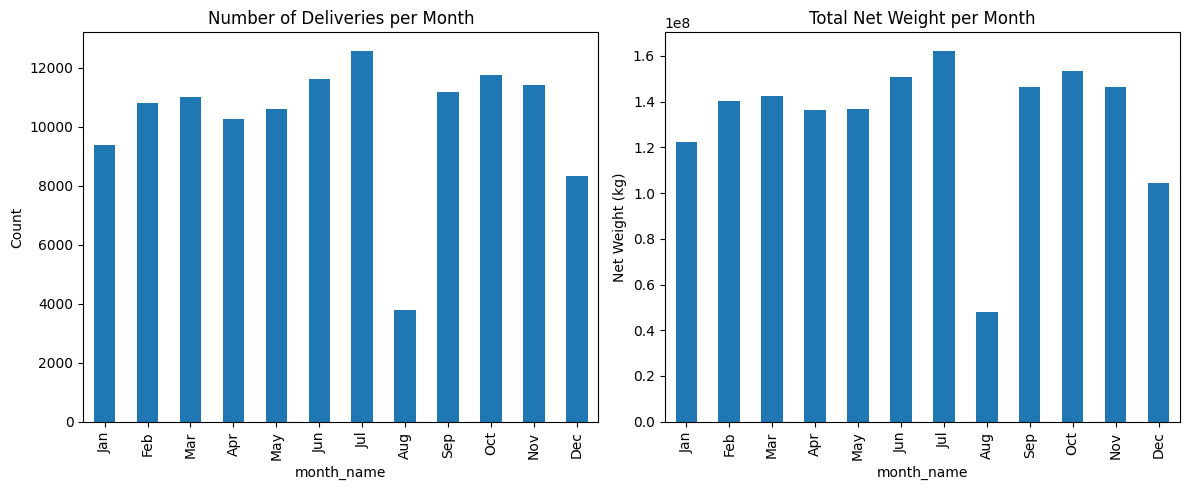

In [10]:

# Remove rows with unvalid/no dates
receivals = receivals.dropna(subset=["date_arrival"])
receivals["year"] = receivals["date_arrival"].dt.year
receivals["month_name"] = receivals["date_arrival"].dt.strftime("%b")

# Define month order
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Group data
yearly_counts = receivals.groupby("year").size()
yearly_weights = receivals.groupby("year")["net_weight"].sum()

monthly_counts = receivals["month_name"].value_counts().reindex(month_order)
monthly_weights = receivals.groupby("month_name")["net_weight"].sum().reindex(month_order)

# Plot yearly overview
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

yearly_counts.plot(kind="bar", ax=axes[0], title="Number of Deliveries per Year")
axes[0].set_ylabel("Count")

yearly_weights.plot(kind="bar", ax=axes[1], title="Total Net Weight per Year")
axes[1].set_ylabel("Net Weight (kg)")

plt.tight_layout()
plt.show()

# Plot monthly overview
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

monthly_counts.plot(kind="bar", ax=axes[0], title="Number of Deliveries per Month")
axes[0].set_ylabel("Count")

monthly_weights.plot(kind="bar", ax=axes[1], title="Total Net Weight per Month")
axes[1].set_ylabel("Net Weight (kg)")

plt.tight_layout()
plt.show()



Less deliveries during the summer months.

#### Deliveries per day of the week

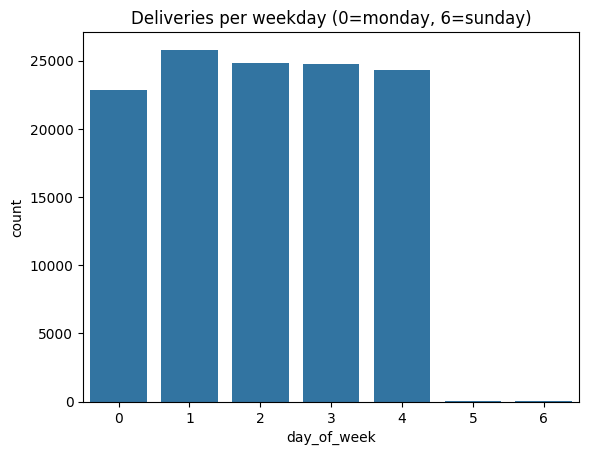

In [11]:
sns.countplot(x="day_of_week", data=receivals)
plt.title("Deliveries per weekday (0=monday, 6=sunday)")
plt.show()

Zero to none deliveries during the weekend. Not so much difference rest of the week.

#### Groups and pair of features

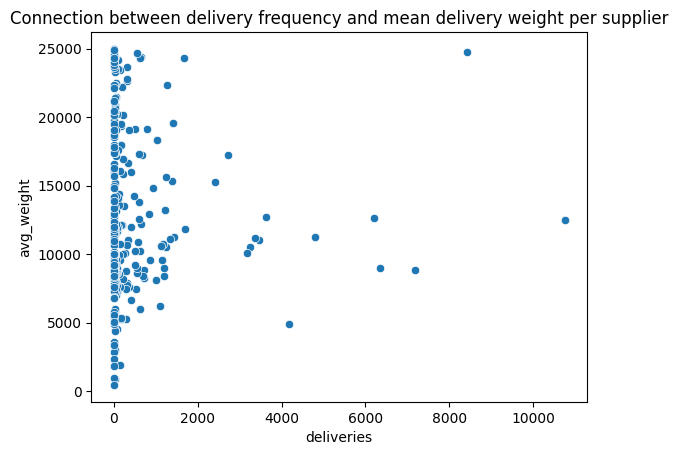

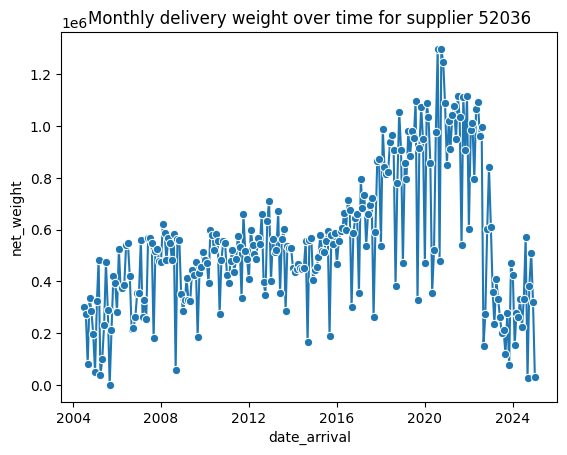

In [12]:
supplier_summary = (
    receivals.groupby("supplier_id")
    .agg(avg_weight=("net_weight", "mean"),
         deliveries=("net_weight", "count"))
    .sort_values("deliveries", ascending=False)
)
sns.scatterplot(data=supplier_summary, x="deliveries", y="avg_weight")
plt.title("Connection between delivery frequency and mean delivery weight per supplier")
plt.show()


top_supplier = (
    receivals["supplier_id"]
    .value_counts()
    .idxmax()
)
monthly_supplier = (
    receivals[receivals["supplier_id"] == top_supplier]
    .groupby(pd.Grouper(key="date_arrival", freq="M"))["net_weight"]
    .sum()
    .reset_index()
)
sns.lineplot(
    data=monthly_supplier,
    x="date_arrival",
    y="net_weight",
    marker='o'
)
plt.title(f"Monthly delivery weight over time for supplier {top_supplier}")
plt.show()



#### Ordered vs delivered quantity

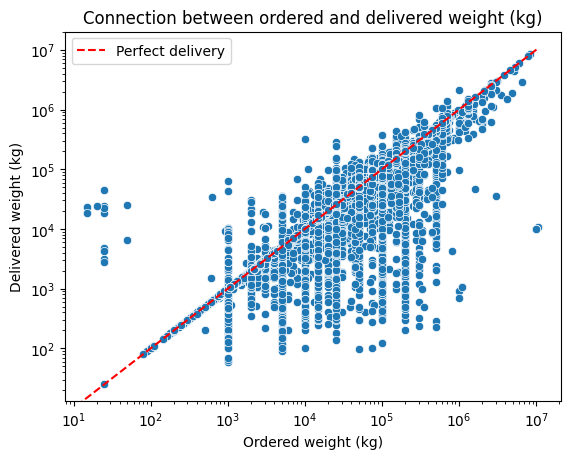

In [13]:
# Merge together receivals og purchase_orders
merged = receivals.merge(
    purchase_orders,
    on=["purchase_order_id", "purchase_order_item_no"],
    how="left"
)

# Convert unit to kg
merged["unit"] = merged["unit"].str.upper() 
merged.loc[merged["unit"] == "PUND", "quantity"] *= 0.4536 
merged = merged[merged["unit"] == "KG"].copy()
merged = merged[merged["quantity"].notna() & (merged["quantity"] > 0)]


# Group by order
order_compare = (
    merged.groupby(["purchase_order_id", "purchase_order_item_no"], as_index=False)
          .agg({
              "quantity": "first",      # total ordered quantity (kg)
              "net_weight": "sum"     # total delivered quantity (kg)
          })
)


sns.scatterplot(data=order_compare, x="quantity", y="net_weight")
plt.title("Connection between ordered and delivered weight (kg)")
plt.xlabel("Ordered weight (kg)")
plt.ylabel("Delivered weight (kg)")

max_val = max(order_compare["quantity"].max(), order_compare["net_weight"].max())
plt.plot([0, max_val], [0, max_val], "r--", label="Perfect delivery")
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.show()


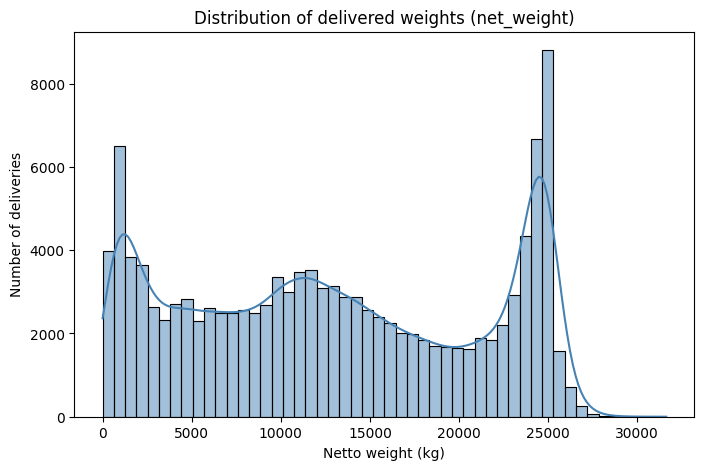

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(receivals["net_weight"], bins=50, kde=True, color="steelblue")
plt.title("Distribution of delivered weights (net_weight)")
plt.xlabel("Netto weight (kg)")
plt.ylabel("Number of deliveries")
plt.show()


#### How expected delivery time and delays are

In [15]:
purchase_orders["delivery_date"] = pd.to_datetime(
    purchase_orders["delivery_date"],
    errors="coerce", 
    utc=True           
).dt.tz_localize(None)  

purchase_orders["created_date_time"] = pd.to_datetime(
    purchase_orders["created_date_time"],
    errors="coerce",  
    utc=True           
).dt.tz_localize(None) 

purchase_orders["lead_time_days"] = (
    pd.to_datetime(purchase_orders["delivery_date"]) - 
    pd.to_datetime(purchase_orders["created_date_time"])
).dt.days

count    32679.000000
mean       368.318033
std        320.826507
min          0.000000
25%        169.000000
50%        279.000000
75%        463.000000
max       6046.000000
Name: modification_delay_days, dtype: float64


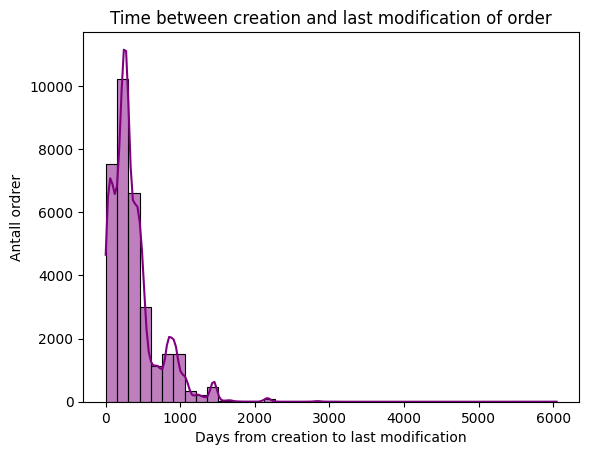

In [16]:
purchase_orders["created_date_time"] = pd.to_datetime(purchase_orders["created_date_time"], errors="coerce").dt.tz_localize(None)
purchase_orders["modified_date_time"] = pd.to_datetime(purchase_orders["modified_date_time"], errors="coerce").dt.tz_localize(None)

purchase_orders["modification_delay_days"] = (
    purchase_orders["modified_date_time"] - purchase_orders["created_date_time"]
).dt.days

print(purchase_orders["modification_delay_days"].describe())

sns.histplot(
    purchase_orders["modification_delay_days"].dropna(),
    bins=40, kde=True, color="purple"
)
plt.title("Time between creation and last modification of order")
plt.xlabel("Days from creation to last modification")
plt.ylabel("Antall ordrer")
plt.show()


In [17]:
merged["date_arrival"] = pd.to_datetime(merged["date_arrival"], errors="coerce", utc=True).dt.tz_localize(None)
merged["delivery_date"] = pd.to_datetime(merged["delivery_date"], errors="coerce", utc=True).dt.tz_localize(None)
merged["created_date_time"] = pd.to_datetime(merged["created_date_time"], utc=True).dt.tz_localize(None)
merged["modified_date_time"] = pd.to_datetime(merged["modified_date_time"], utc=True).dt.tz_localize(None)

merged["delay_days"] = (merged["date_arrival"] - merged["delivery_date"]).dt.days


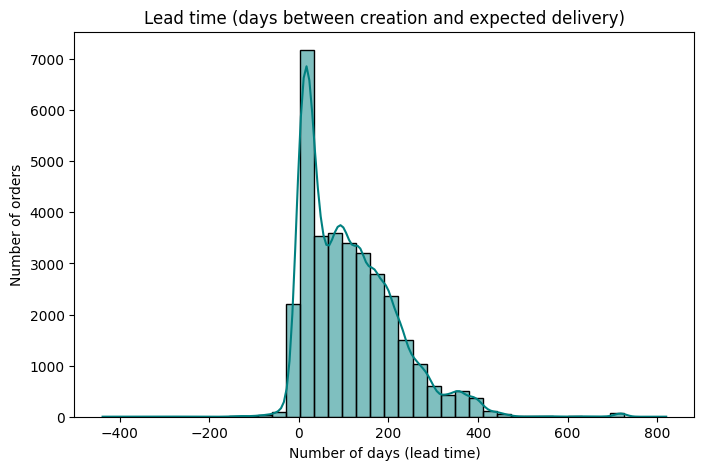

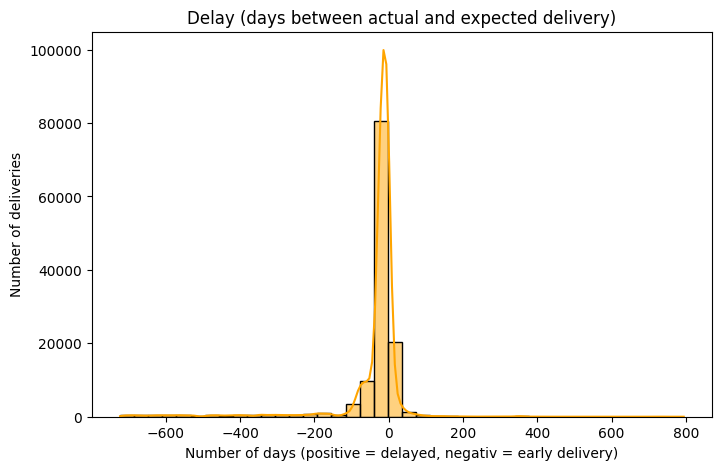

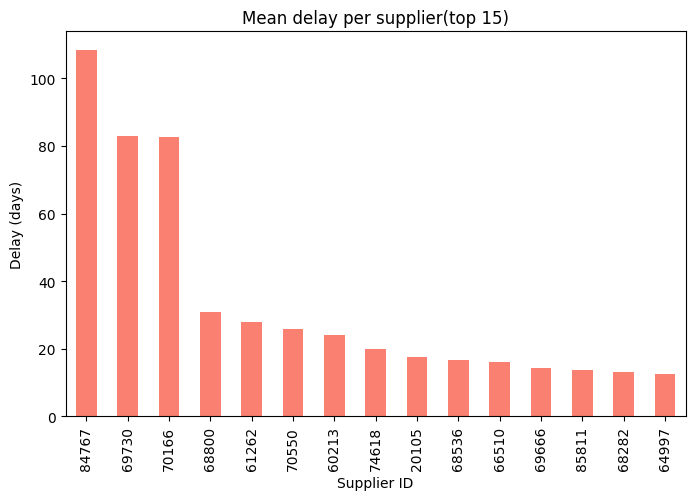

Mean lead time: 114.50447680202586
Median lead time: 95.0
Mean delay: -35.5955600897776
Median delay: -15.0


In [18]:
# Plot lead time
plt.figure(figsize=(8,5))
sns.histplot(purchase_orders["lead_time_days"].dropna(), bins=40, kde=True, color="teal")
plt.title("Lead time (days between creation and expected delivery)")
plt.xlabel("Number of days (lead time)")
plt.ylabel("Number of orders")
plt.show()

# Plot delays
plt.figure(figsize=(8,5))
sns.histplot(merged["delay_days"].dropna(), bins=40, kde=True, color="orange")
plt.title("Delay (days between actual and expected delivery)")
plt.xlabel("Number of days (positive = delayed, negativ = early delivery)")
plt.ylabel("Number of deliveries")
plt.show()

# Analysis per supplier
supplier_delay = (
    merged.groupby("supplier_id")["delay_days"]
    .mean()
    .dropna()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(8,5))
supplier_delay.plot(kind="bar", color="salmon")
plt.title("Mean delay per supplier(top 15)")
plt.ylabel("Delay (days)")
plt.xlabel("Supplier ID")
plt.show()

print("Mean lead time:", purchase_orders["lead_time_days"].mean())
print("Median lead time:", purchase_orders["lead_time_days"].median())
print("Mean delay:", merged["delay_days"].mean())
print("Median delay:", merged["delay_days"].median())


In [19]:
merged_df = receivals.merge(
    purchase_orders[["purchase_order_id", "purchase_order_item_no", "quantity"]],
    on=["purchase_order_id", "purchase_order_item_no"],
    how="inner"
)

In [20]:
merged_df = merged_df.drop(columns = ["batch_id", "receival_status", "month", "day_of_week", "month_name", "year"])
merged_df = merged_df[merged_df["date_arrival"] > "2023-01-01"]
merged_df = merged_df[["rm_id", "net_weight", "quantity"]]

In [21]:
merged_df = (
    merged_df.groupby("rm_id", as_index=False)[["quantity", "net_weight"]]
             .sum()
             .rename(columns={"quantity": "total_quantity", "net_weight": "total_net_weight"})
)

In [22]:
merged_df

,rm_id,total_quantity,total_net_weight
0,2123.0,4.000000e+04,40000.0
1,2124.0,2.808000e+04,28080.0
2,2125.0,1.322130e+05,131930.0
3,2129.0,1.250000e+06,352620.0
4,2130.0,1.249206e+09,25221986.0
...,...,...,...
67,4461.0,1.500000e+04,2500.0
68,4462.0,1.500000e+04,3600.0
69,4463.0,1.500000e+04,2000.0
70,4481.0,5.000000e+04,47020.0


#### Purchase orders to receivals mapping

product to rm_id mapping (avg rmid per product id og motsatt) - stats på antall som er 1:1 - noen rmidr erstattes av andre (plot dette for å se(prøv en av de med mange rmidr))

In [23]:
#What rmids fit to which purchase orders
poid_to_rmid_map =(
    receivals
    .groupby(['product_id'])['rm_id']
    .agg([
        ('n_rm_ids', lambda x: x.nunique()),
        ('rm_id_list', lambda x: sorted(x.unique()))
    ])
    .reset_index()
)
avg_rmid_per_productid = poid_to_rmid_map['n_rm_ids'].mean()

print(f'the mean amount of rm ids per product id: {avg_rmid_per_productid}')


poid_to_rmid_map.head()

the mean amount of rm ids per product id: 3.7777777777777777


,product_id,n_rm_ids,rm_id_list
0,1002.0,1,[383.0]
1,1025.0,1,[2402.0]
2,1026.0,3,"[2521.0, 3601.0, 3621.0]"
3,1034.0,1,[2125.0]
4,1160.0,2,"[1876.0, 2124.0]"


In [24]:
#What purchase orders fit to which rmids
rmis_to_poid_map =(
    receivals
    .groupby(['rm_id'])['product_id']
    .agg([
        ('n_po', lambda x: x.nunique()),
        ('po_list', lambda x: sorted(x.unique()))
    ])
    .reset_index()
)
avg_productid_per_rmid = rmis_to_poid_map['n_po'].mean()

print(f'the mean amount of product ids per rm_id: {avg_productid_per_rmid}')


print(rmis_to_poid_map[rmis_to_poid_map['n_po'] > 1])



the mean amount of product ids per rm_id: 1.0049261083743843
      rm_id  n_po                   po_list
161  3362.0     2  [91900272.0, 91902090.0]


There is only one rm_id with two purchase order ids, this is rm_id 3362

In [25]:
#We try to find a pattern in product ids with multiple rm_ids

poid_multiple_rmid = poid_to_rmid_map[poid_to_rmid_map['n_rm_ids'] > 1]

poid_multiple_rmid.head()

,product_id,n_rm_ids,rm_id_list
2,1026.0,3,"[2521.0, 3601.0, 3621.0]"
4,1160.0,2,"[1876.0, 2124.0]"
5,1177.0,3,"[380.0, 1871.0, 2123.0]"
6,1307.0,3,"[387.0, 1873.0, 2161.0]"
7,1414.0,2,"[1874.0, 2122.0]"


In [26]:
rmis_to_poid_map.head()

,rm_id,n_po,po_list
0,342.0,1,[91900170.0]
1,343.0,1,[91900143.0]
2,345.0,1,[91900143.0]
3,346.0,1,[91900146.0]
4,347.0,1,[91900143.0]


In [27]:

# Filter dataframes
poid_to_rmid_1t1 = poid_to_rmid_map[poid_to_rmid_map["n_rm_ids"] == 1]
non_121_rmid_to_po = rmis_to_poid_map[rmis_to_poid_map["n_po"] > 1]

# Get list of rm_ids that belong to >1 purchase order
non_121_rmids = set(non_121_rmid_to_po["rm_id"])

# Keep only 1-to-1 rm_ids that are not in that list
one_to_one_rmid = poid_to_rmid_1t1[
    poid_to_rmid_1t1["rm_id_list"].apply(lambda x: int(x[0]) not in non_121_rmids)
]

#Count unique rm_ids
n_1t1 = len(set(int(x[0]) for x in one_to_one_rmid["rm_id_list"]))
n_rm_ids = receivals['rm_id'].nunique()

print(f"We have {n_1t1} unique rm_ids in strict 1-to-1 mapping, this is {n_1t1/n_rm_ids * 100:.2f}% of the total rm_ids")


We have 15 unique rm_ids in strict 1-to-1 mapping, this is 7.39% of the total rm_ids


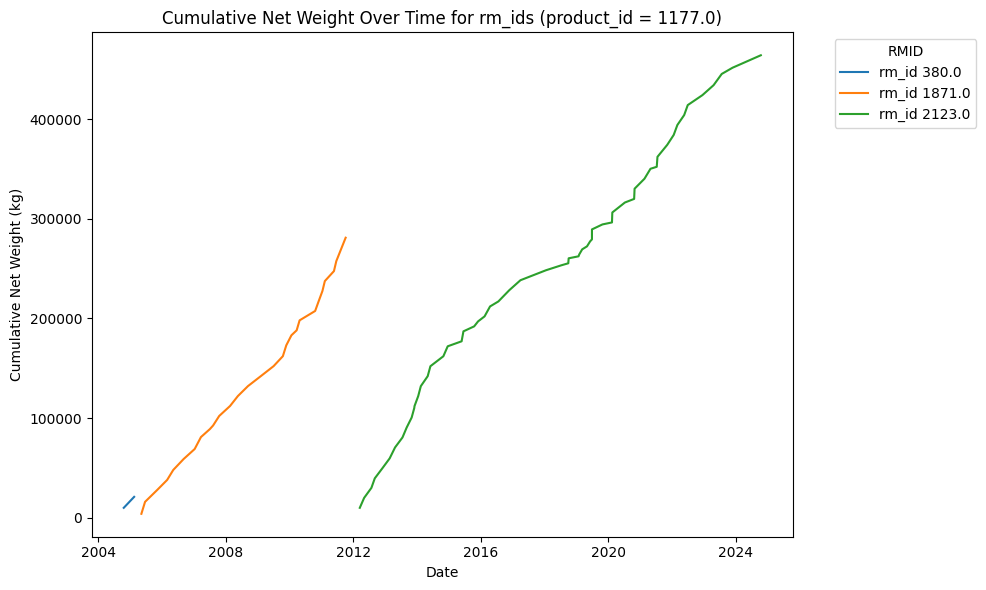

In [28]:
# Flatten all rm_ids from those purchase orders into one list
first_po = poid_multiple_rmid['product_id'].iloc[2]
#rmids_to_plot = poid_multiple_rmid[poid_multiple_rmid['product_id'] == first_po]['rm_id_list']
rmids_to_plot = sorted(set(
    rmid for sublist in poid_multiple_rmid.loc[
        poid_multiple_rmid['product_id'] == first_po, 'rm_id_list'
    ] for rmid in sublist
))


plt.figure(figsize=(10, 6))

for rmid in rmids_to_plot:
    df_rmid = receivals[receivals["rm_id"] == rmid].sort_values("date_arrival")
    if df_rmid.empty:
        continue
    df_rmid["cum_weight"] = df_rmid["net_weight"].cumsum()
    plt.plot(df_rmid["date_arrival"], df_rmid["cum_weight"], label=f"rm_id {rmid}")

plt.title(f"Cumulative Net Weight Over Time for rm_ids (product_id = {first_po})")
plt.xlabel("Date")
plt.ylabel("Cumulative Net Weight (kg)")
plt.legend(title="RMID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

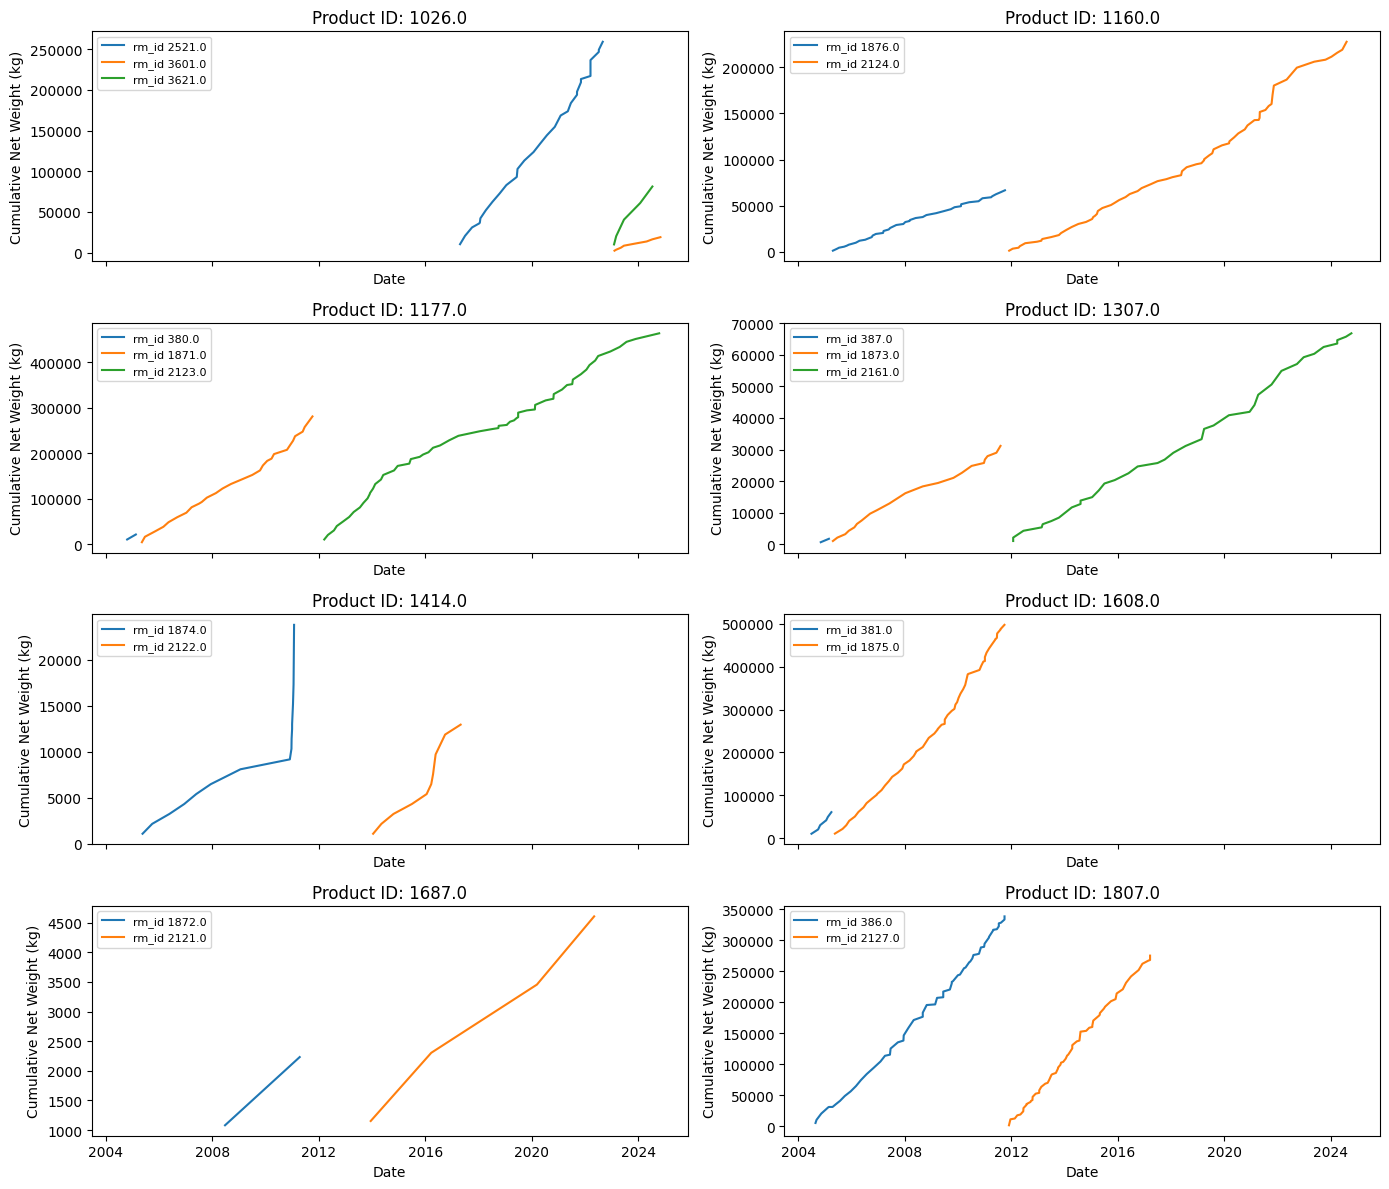

In [29]:
# Ensure date format
receivals["date_arrival"] = pd.to_datetime(receivals["date_arrival"], errors="coerce")

# Get the first 8 unique product_ids from the multi-rmid POs
product_ids = poid_multiple_rmid["product_id"].unique()[:8]

# Create subplots
fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()

for i, product_id in enumerate(product_ids):
    # Get all rm_ids associated with this product_id
    rmids_to_plot = sorted(set(
        rmid for sublist in poid_multiple_rmid.loc[
            poid_multiple_rmid["product_id"] == product_id, "rm_id_list"
        ] for rmid in sublist
    ))
    
    ax = axes[i]
    
    # Plot cumulative weight for each rm_id
    for rmid in rmids_to_plot:
        df_rmid = receivals[receivals["rm_id"] == rmid].sort_values("date_arrival")
        if df_rmid.empty:
            continue
        df_rmid["cum_weight"] = df_rmid["net_weight"].cumsum()
        ax.plot(df_rmid["date_arrival"], df_rmid["cum_weight"], label=f"rm_id {rmid}")

    ax.set_title(f"Product ID: {product_id}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative Net Weight (kg)")
    ax.legend(fontsize=8, loc="upper left")

# Remove empty subplots if fewer than 8
for j in range(len(product_ids), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


We can see that often for rmids with the same product ids - the other rmids start arriving when the last one stopps. This is relevent for our mapping later

#### Look at registered weights

In [30]:
receivals[receivals['purchase_order_id'] == 312688.0].head()

,rm_id,product_id,purchase_order_id,purchase_order_item_no,receival_item_no,batch_id,date_arrival,receival_status,net_weight,supplier_id,date,year,doy,month,day_of_week,month_name
103854,3265.0,91901460.0,312688.0,10.0,1,1018976.0,2021-12-01 14:55:00+01:00,Completed,180.0,79610,2021-12-01,2021,335,12,2,Dec
103884,3265.0,91901460.0,312688.0,10.0,1,1019150.0,2021-12-02 14:49:00+01:00,Completed,1.0,79610,2021-12-02,2021,336,12,3,Dec
104273,3265.0,91901460.0,312688.0,10.0,1,1022415.0,2021-12-22 13:50:00+01:00,Completed,23540.0,79610,2021-12-22,2021,356,12,2,Dec
104312,3265.0,91901460.0,312688.0,10.0,1,1022911.0,2022-01-03 11:17:00+01:00,Completed,22340.0,79610,2022-01-03,2022,3,1,0,Jan
104336,3265.0,91901460.0,312688.0,10.0,1,1022941.0,2022-01-04 13:17:00+01:00,Completed,22220.0,79610,2022-01-04,2022,4,1,1,Jan


## Linear regression + XGBoost/Catboost/LightGBM classification

This pipeline predicts which raw materials should be treated as continuing into the next year and, for those, how their cumulative deliveries evolve.
It combines continuation classifier with a extrapolated linear trend.

### 1. Feature Engineering


Historical deliveries and purchase orders are transformed into yearly summaries per `rm_id`:

- **Cumulative trend features:** average delivered volume over the last 1, 3, 6, and 12 months, expressed as log-ratios (short/medium/long).
- **Order & fill-rate features:** analogous ratios for ordered quantities and fill rates.
- **Activity indicators:** yearly receival counts and recency of deliveries,



### 2. Historical Training Data


For each (`rm_id`, `year`), the model:

- Computes cumulative delivered weight at a fixed anchor date in year $t$ and at the same date in year $t{+}1$.
- Labels the pair as continuing if year $t{+}1$ reaches more than a chosen fraction (30%) of year $t$; otherwise non-continuing.


### 3. Modeling and Validation

- Three gradient boosting classifiers — `LightGBM`, `XGBoost`, and `CatBoost` — are trained on this binary continuation target.
- A forward feature selection procedure keeps only variables that improve out-of-sample log-loss.
- Validation is performed on a held-out recent year, ensuring that continuation probabilities reflect genuine forward-looking behavior.
- Model outputs are combined via an optimized weighted ensemble to obtain a calibrated continuation probability per (`rm_id`, `year`).

### 4. Trend Extrapolation


- A quantile regression is fitted to the last 12 months of cumulative deliveries as a function of day-of-year.
- The fitted line is re-based and extended into the next year, yielding an interpretable cumulative forecast:
*“If this RM continues, its next-year trajectory follows this extrapolated curve.”*

### 5. Final Forecast


For each RM:

- If the continuation probability falls below the threshold, the extrapolated curve is discarded (effectively zeroed).
- If it exceeds the threshold, the extrapolated cumulative curve is kept as the forecast.

The final outputs are thus driven by two transparent components:
a continuation decision based on long-run behavior and a linear, data-backed extrapolation for expected volume.

#### Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.linear_model import QuantileRegressor 
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

import os

#### Load and clean data

In [32]:
# Load data
purchase_orders_df = pd.read_csv('data/kernel/purchase_orders.csv') #Må nok endres
rec_df = pd.read_csv('data/kernel/receivals.csv')
pred_map = pd.read_csv('data/prediction_mapping.csv')

#  Convert to datetime and correct timezone  
purchase_orders_df[['delivery_date', 'created_date_time', 'modified_date_time']] = (
    purchase_orders_df[['delivery_date', 'created_date_time', 'modified_date_time']]
    .apply(pd.to_datetime, utc=True)
)

# Convert all to local Oslo time
for col in ['delivery_date', 'created_date_time', 'modified_date_time']:
    purchase_orders_df[col] = purchase_orders_df[col].dt.tz_convert('Europe/Oslo')

#   Create derived time-based features  
purchase_orders_df['expected'] = pd.to_datetime(purchase_orders_df['delivery_date'].dt.date)
purchase_orders_df['ordered'] = pd.to_datetime(purchase_orders_df['created_date_time'].dt.date)
purchase_orders_df['year'] = purchase_orders_df['created_date_time'].dt.year.astype(int)
purchase_orders_df['month'] = purchase_orders_df['created_date_time'].dt.month.astype(int)

#   Convert quantity from pounds to kilograms  
mask_pounds = purchase_orders_df['unit'] == 'PUND'
purchase_orders_df.loc[mask_pounds, 'quantity'] *= 0.45359237
purchase_orders_df.loc[mask_pounds, 'unit'] = 'KG'
purchase_orders_df = purchase_orders_df[purchase_orders_df['status'] != 'Deleted']
purchase_orders_df = purchase_orders_df[purchase_orders_df['quantity'] > 0]

#   Process receivals  
rec_df['date_arrival'] = pd.to_datetime(rec_df['date_arrival'], utc=True).dt.tz_convert('Europe/Oslo')
rec_df['date'] = pd.to_datetime(rec_df['date_arrival'].dt.date)
rec_df['year'] = rec_df['date_arrival'].dt.year.astype(int)

#   Process prediction mapping  
pred_map['date'] = pd.to_datetime(pred_map['forecast_end_date'])

#   Clean data  
# Drop rows with missing rm_id
rec_df = rec_df.dropna(subset=['rm_id'])
rec = rec_df.dropna(subset=['product_id', 'rm_id'])

# Keep only positive weights and quantities
rec_df = rec_df[rec_df['net_weight'] > 0]





#### Features

In [33]:

rm_id_to_product_id = (rec.groupby('rm_id')['product_id'].apply(lambda x: sorted(x.unique().tolist())).to_dict())

product_id_to_rm_id = (rec.groupby('product_id')['rm_id'].apply(lambda x: sorted(x.unique().tolist())).to_dict())

active_rec = rec_df[rec_df['year'] >= 2024].dropna(subset=['product_id', 'rm_id'])

product_id_to_rm_id_active = (active_rec.groupby('product_id')['rm_id'].apply(lambda x: sorted(x.unique().tolist())).to_dict())

rm_id_to_product_id_active = (active_rec.groupby('rm_id')['product_id'].apply(lambda x: sorted(x.unique().tolist())).to_dict())


#### Orderes

In [34]:
#   Create aggregated receivals (summarized per order item)  
aggrigated_recievlas = (
    rec_df
    .groupby(['product_id', 'purchase_order_id', 'purchase_order_item_no'], as_index=False)
    .agg(
        rm_id=('rm_id', 'first'),
        net_weight=('net_weight', 'sum'),
        date_min=('date', 'min'),
        date_max=('date', 'max')
    )
)

#   Construct the  orders by merging purchase orders and receivals  
orders = (
    purchase_orders_df[
        [
            'product_id', 'purchase_order_id', 'purchase_order_item_no',
            'quantity', 'ordered', 'expected',
            'status', 'month', 'year'
        ]
    ]
    .merge(
        aggrigated_recievlas,
        on=['product_id', 'purchase_order_id', 'purchase_order_item_no'],
        how='left'
    )
)

#   Count number of orders per product per year  
df_opy = (orders.groupby(['year', 'product_id']).agg(num_orders=('product_id', 'size')).reset_index())

# Merge order counts back into the  orders
orders =  orders.merge(
    df_opy[['year', 'product_id', 'num_orders']],
    on=['year', 'product_id'],
    how='left',
    validate='many_to_one'
)

#   Filter orders expected in 2025 and placed from Q4 2024 onward  
_25expected_ob = (
     orders[
        ( orders['expected'] >= pd.to_datetime('2025-01-01')) &
        ( orders['ordered'] >= pd.to_datetime('2024-10-01'))
    ]
    .reset_index(drop=True)
)

# Subset of low-activity orders (≤ 20 orders per product, no recorded receival)
_25expected_ob_low = (
    _25expected_ob[_25expected_ob['num_orders'] <= 20]
    .reset_index(drop=True)
)
_25expected_ob_low = _25expected_ob_low[_25expected_ob_low['net_weight'].isna()]

#   Identify expected raw materials for 2025  
ex_25_rms = []
for product_id in _25expected_ob['product_id'].unique():
    rms = product_id_to_rm_id_active[product_id]
    if len(rms) == 1:
        ex_25_rms.append(rms[0])

# LIST: all rm_id's and active rm_id's (active in 2024)
all_rms = rec_df['rm_id'].unique()
active_rms = rec_df[rec_df['year'] == 2024]['rm_id'].unique()

In [35]:
# DF: full date grid for each rm_id since its inception
end = pd.Timestamp('2025-05-31')

date_min = (rec_df
             .groupby('rm_id', as_index=False)['date'].min()
             .rename(columns={'date': 'start_date'}))

grid_d = (date_min
      .assign(date_range=date_min['start_date'].apply(lambda d: pd.date_range(d, pd.Timestamp('2025-05-31'), freq='D')))
      .drop(columns='start_date')
      .explode('date_range')
      .rename(columns={'date_range': 'date'})
      .reset_index(drop=True))


In [36]:
#   Initialize dataframe from date grid  
df = grid_d.copy()

#   Extract temporal features from date 
df['day_of_week'] = df['date'].dt.day_of_week.astype(int)
df['is_weekend'] = df['day_of_week'] >= 5 
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month.astype(int)
df['doy'] = df['date'].dt.day_of_year.astype(int)
df['year'] = df['date'].dt.year.astype(int)


#   Map rm_id to product_id (mostly one-to-one, except rm_id = 3362)  
df['product_id'] = df['rm_id'].apply(lambda x: rm_id_to_product_id.get(x, [None])[0])

#   Aggregate receivals by rm_id and date  
aggrigated_rec = (
    rec_df
    .groupby(['rm_id', 'date'], as_index=False)
    .agg(
        net_weight=('net_weight', 'sum'),
        receival_count=('net_weight', lambda x: (x > 0).sum())
    )
)

#   Merge receival aggregates into date grid  
df = df.merge(
    aggrigated_rec[['rm_id', 'date', 'net_weight', 'receival_count']],
    on=['rm_id', 'date'],
    how='left'
)

#   Fill missing receival data with zeros  
df['net_weight'] = df['net_weight'].fillna(0)
df['receival_count'] = df['receival_count'].fillna(0)


#   Compute cumulative received weight per rm_id per year  
df['cum_weight'] = (df.sort_values(['rm_id', 'date']).groupby(['rm_id', 'year'])['net_weight'].cumsum())

#   Update date grid with enriched features  
grid_d = df.copy()


In [37]:
#   Aggregate monthlyordered quantities per product  
qty = (
    purchase_orders_df
    .groupby(['product_id', 'month', 'year'])
    .agg({
        'product_id': 'first',
        'month': 'first',
        'year': 'first',
        'quantity': 'sum'
    })
    .reset_index(drop=True)
)

#   Identify first available month per product  
fdates = (
    qty
    .groupby('product_id')[['year', 'month']]
    .apply(lambda x: pd.Timestamp(year=x['year'].min(), month=x['month'].min(), day=1))
)

#   Create continuous monthly grid from first observed month to Dec 2024  
rows_exp = []
for pid, start_date in fdates.items():
    end_date = pd.Timestamp(year=2024, month=12, day=1)
    all_months = pd.date_range(start=start_date, end=end_date, freq='MS')
    rows_exp.extend([(pid, d.year, d.month) for d in all_months])

expanded_df = pd.DataFrame(rows_exp, columns=['product_id', 'year', 'month'])

#   Merge monthly quantity data with expanded month grid  
qty = (
    expanded_df
    .merge(qty, on=['product_id', 'year', 'month'], how='left')
    .fillna({'quantity': 0})
    .sort_values(['product_id', 'year', 'month'])
    .reset_index(drop=True)
)

#   Merge monthly quantities into date grid  
grid_d = grid_d.merge(
    qty,
    on=['product_id', 'month', 'year'],
    how='left',
    validate='many_to_one'
)

#   Prepare main dataframe  
df = grid_d.copy().sort_values(['rm_id', 'date'])


#total

def sum_year(group):
    """Summarize yearly quantities and receivals for each rm_id."""
    results = []

    for year, data in group.groupby(group['date'].dt.year):
        year_data = data[data['date'].dt.year == year]
        if year_data.empty:
            continue

        #   Define lookback windows (1–12 months)  
        last_date = year_data['date'].max()
        windows = {
            i: year_data[year_data['date'] >= last_date - pd.DateOffset(months=i)]
            for i in range(1, 13)
        }

        #   Extract monthly quantities (handling potential empty slices)  
        q = {
            i: (windows[i]['quantity'].iloc[-1] if len(windows[i]) > 0 else 0)
            for i in range(1, 13)
        }

        #   Rolling cumulative order quantities  
        quntety_3m = q[1] + q[2] + q[3]
        quntety_6m = quntety_3m + q[4] + q[5] + q[6]
        quntety_12m = quntety_6m + q[7] + q[8] + q[9] + q[10] + q[11] + q[12]

        #   Append summary metrics for the year  
        results.append({
            'rm_id': data['rm_id'].iloc[0],
            'product_id': data['product_id'].iloc[0],
            'year': year,
            'cumulative_weight1M_mean': windows[1]['net_weight'].sum(),
            'cumulative_weight3M_mean': windows[3]['net_weight'].sum() / 3,
            'cumulative_weight6M_mean': windows[6]['net_weight'].sum() / 6,
            'cumulative_weight12M_mean': year_data['net_weight'].sum() / 12,
            'receival_count_year': year_data['receival_count'].sum(),
            'quntety_1M': q[1],
            'quntety_3M': quntety_3m / 3,
            'quntety_6M': quntety_6m / 6,
            'quntety_12M': quntety_12m / 12,
        })

    return pd.DataFrame(results)


#   Apply yearly summary per rm_id  
master_df = (
    df
    .groupby('rm_id', group_keys=False)
    .apply(sum_year)
    .reset_index(drop=True)
)


In [38]:

#   Log trends for cumulative weight (cw)  
master_df['log_cumulative_weightshort_trend']  = np.log((master_df['cumulative_weight1M_mean']  + 1e-6) / (master_df['cumulative_weight3M_mean']  + 1e-6))
master_df['log_cumulative_weightmedium_trend'] = np.log((master_df['cumulative_weight3M_mean']  + 1e-6) / (master_df['cumulative_weight6M_mean']  + 1e-6))
master_df['log_cumulative_weightlong_trend']   = np.log((master_df['cumulative_weight3M_mean']  + 1e-6) / (master_df['cumulative_weight12M_mean'] + 1e-6))


#   Log trends for order quantities (q)  
master_df['log_quntety_short_trend']   = np.log((master_df['quntety_1M']  + 1e-6) / (master_df['quntety_3M']  + 1e-6))
master_df['log_quntety_medium_trend']  = np.log((master_df['quntety_3M']  + 1e-6) / (master_df['quntety_6M']  + 1e-6))
master_df['log_quntety_long_trend']    = np.log((master_df['quntety_3M']  + 1e-6) / (master_df['quntety_12M'] + 1e-6))

#   Compute fill rates (delivered vs.ordered)  
master_df['fillr1M']  = master_df['cumulative_weight1M_mean']  / (master_df['quntety_1M']  + 1e-6)
master_df['fillr3M']  = master_df['cumulative_weight3M_mean']  / (master_df['quntety_3M']  + 1e-6)
master_df['fillr6M']  = master_df['cumulative_weight6M_mean']  / (master_df['quntety_6M']  + 1e-6)
master_df['fillr12M'] = master_df['cumulative_weight12M_mean'] / (master_df['quntety_12M'] + 1e-6)

#   Log trends for fill rate (fr)  
master_df['log_fill_rate_short_trend']  = np.log((master_df['fillr1M']  + 1e-6) / (master_df['fillr3M']  + 1e-6))
master_df['log_fill_rate_medium_trend'] = np.log((master_df['fillr3M']  + 1e-6) / (master_df['fillr6M']  + 1e-6))
master_df['log_fill_rate_long_trend']   = np.log((master_df['fillr3M']  + 1e-6) / (master_df['fillr12M'] + 1e-6))


In [39]:
#   Create working copy  
features_df = master_df.copy()

#   Define current and target reference dates  
features_df['current_date'] = pd.to_datetime(features_df['year'], format='%Y') + pd.DateOffset(months=4, days=30)
features_df['target_date']  = pd.to_datetime(features_df['year'] + 1, format='%Y') + pd.DateOffset(months=4, days=30)

#   Merge cumulative weight (current year)  
features_df = features_df.merge(grid_d[['rm_id', 'date', 'cum_weight']],left_on=['rm_id', 'current_date'],right_on=['rm_id', 'date'],how='left'
).rename(columns={'cum_weight': 'current_cumulativ_weight'})

#   Merge cumulative weight (next year)  
features_df = features_df.merge(grid_d[['rm_id', 'date', 'cum_weight']],left_on=['rm_id', 'target_date'],right_on=['rm_id', 'date'],how='left'
).rename(columns={'cum_weight': 'target_cumulativ_weight'})

#   Drop redundant date columns  
features_df = features_df.drop(columns=['date_x', 'date_y'])

#   Compute target ratio and binary indicator  
features_df['target'] = features_df['target_cumulativ_weight'] / features_df['current_cumulativ_weight']
features_df['target'] = (features_df['target_cumulativ_weight'] / features_df['current_cumulativ_weight'] > 0.3).astype(int)


#### Training

##### Feature Selection

In [40]:
#imports

from sklearn.metrics import (
    log_loss as calc_logloss,
    accuracy_score as calc_acc,
    f1_score as calc_f1,
    roc_auc_score as calc_auc
)

from lightgbm import LGBMClassifier as LGBModel, early_stopping as lgb_early_stop, log_evaluation as lgb_log_eval
from xgboost import XGBClassifier as XGBModel
from catboost import CatBoostClassifier as CatModel, Pool as CatPool


#data prep

data_filtered = features_df.query("year >= 2013 and cumulative_weight12M_mean > 0 and receival_count_year > 0").copy()

train_df = data_filtered.loc[data_filtered['year'] < 2023].dropna(subset=['target'])
val_df   = data_filtered.loc[data_filtered['year'] == 2023].dropna(subset=['target'])
pred_df  = features_df.query("year == 2024 and cumulative_weight12M_mean > 0").copy()

cat_cols = ['rm_id', 'product_id']

base_feats = [
    'year', 'receival_count_year',
    'fillr1M', 'fillr3M',
    'fillr6M', 'fillr12M',
    'log_cumulative_weightshort_trend', 'log_cumulative_weightmedium_trend',
    'log_cumulative_weightlong_trend', 'log_quntety_short_trend',
    'log_quntety_medium_trend', 'log_quntety_long_trend',
    'log_fill_rate_short_trend', 'log_fill_rate_medium_trend',
    'log_fill_rate_long_trend'
]
cat_feat_cols = base_feats + cat_cols


X_tr, y_tr = train_df[base_feats], train_df['target']
X_va, y_va = val_df[base_feats], val_df['target']
X_te        = pred_df[base_feats]


def build_catboost_input(df_input):
    """Convert categorical features to string for CatBoost."""
    df_copy = df_input[cat_feat_cols].copy()
    for cat in cat_cols:
        df_copy[cat] = df_copy[cat].astype(str)
    return df_copy

X_tr_cb = build_catboost_input(train_df)
X_va_cb = build_catboost_input(val_df)
X_te_cb = build_catboost_input(pred_df)

cat_feature_indices = [X_tr_cb.columns.get_loc(c) for c in cat_cols]


import numpy as np
import pandas as pd

if len(base_feats) > 1:
    all_feats = base_feats.copy()
    selected_feats, remaining_feats = [], all_feats.copy()
    best_loss = np.inf
    has_improved = True

    tolerance = 0.0
    min_feat_num = 5

    while has_improved and len(remaining_feats) > 0:
        has_improved = False
        best_feat, best_candidate_loss = None, best_loss
        best_any_feat, best_any_loss = None, np.inf

        for feat_name in remaining_feats:
            curr_cols = selected_feats + [feat_name]
            temp_lgb = LGBModel(
                n_estimators=2000, learning_rate=0.02, num_leaves=31,
                min_data_in_leaf=20, subsample=0.9, colsample_bytree=0.8,
                reg_alpha=0.0, reg_lambda=5.0, random_state=42,
                objective="binary"
            )
            temp_lgb.fit(
                train_df[curr_cols], y_tr,
                eval_set=[(val_df[curr_cols], y_va)],
                eval_metric="logloss",
                callbacks=[lgb_early_stop(100), lgb_log_eval(0)]
            )

            val_pred_prob = temp_lgb.predict_proba(val_df[curr_cols])[:, 1]
            loss_value = calc_logloss(y_va, val_pred_prob)

            if loss_value < best_any_loss:
                best_any_loss, best_any_feat = loss_value, feat_name
            if loss_value + tolerance <= best_candidate_loss:
                best_candidate_loss, best_feat = loss_value, feat_name

        if best_feat:
            selected_feats.append(best_feat)
            remaining_feats.remove(best_feat)
            best_loss, has_improved = best_candidate_loss, True
        elif len(selected_feats) < min_feat_num and best_any_feat:
            selected_feats.append(best_any_feat)
            remaining_feats.remove(best_any_feat)
            has_improved = True
        else:
            break

    if not selected_feats:
        selected_feats = all_feats

    base_feats = selected_feats
    cat_feat_cols = base_feats + cat_cols

    X_tr, y_tr = train_df[base_feats], train_df['target']
    X_va, y_va = val_df[base_feats], val_df['target']
    X_te        = pred_df[base_feats]

    X_tr_cb, X_va_cb, X_te_cb = map(build_catboost_input, [train_df, val_df, pred_df])
    cat_feature_indices = [X_tr_cb.columns.get_loc(c) for c in cat_cols]

    print(f"[FS] Selected {len(base_feats)} features (logloss={best_loss:.6f}): {base_feats}")

    X_all = pd.concat([X_tr, X_va], axis=0)
    y_all = pd.concat([y_tr, y_va], axis=0)
    X_all_cb = build_catboost_input(pd.concat([train_df, val_df], axis=0))



lgb_model = LGBModel(
    n_estimators=2000, learning_rate=0.02, num_leaves=31,
    min_data_in_leaf=20, subsample=0.9, colsample_bytree=0.8,
    reg_alpha=0.0, reg_lambda=5.0, random_state=42, objective="binary"
)

xgb_model = XGBModel(
    n_estimators=2000, learning_rate=0.02, max_depth=6, min_child_weight=2,
    subsample=0.9, colsample_bytree=0.8, reg_alpha=0.0, reg_lambda=5.0,
    objective="binary:logistic", random_state=42,
    tree_method="hist", eval_metric="logloss"
)

cat_model = CatModel(
    iterations=2000, learning_rate=0.02, depth=6, l2_leaf_reg=5.0,
    subsample=0.9, rsm=0.8, random_seed=42,
    loss_function='Logloss', eval_metric='Logloss', verbose=False
)



lgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_va, y_va)],
    eval_metric="logloss",
    callbacks=[lgb_early_stop(100), lgb_log_eval(0)]
)

xgb_model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)])

cat_train_pool = CatPool(X_tr_cb, y_tr, cat_features=cat_feature_indices)
cat_val_pool   = CatPool(X_va_cb, y_va, cat_features=cat_feature_indices)
cat_model.fit(cat_train_pool, eval_set=cat_val_pool, use_best_model=True, early_stopping_rounds=100)



val_prob_lgb = lgb_model.predict_proba(X_va)[:, 1]
val_prob_xgb = xgb_model.predict_proba(X_va)[:, 1]
val_prob_cat = cat_model.predict_proba(cat_val_pool)[:, 1]

val_cls_lgb = (val_prob_lgb > 0.5).astype(int)
val_cls_xgb = (val_prob_xgb > 0.5).astype(int)
val_cls_cat = (val_prob_cat > 0.5).astype(int)




lowest_logloss = np.inf
opt_w_lgb = opt_w_xgb = opt_w_cat = None

for w_lgb in np.linspace(0, 1, 101):
    for w_xgb in np.linspace(0, 1, 101):
        w_cat = 1 - w_lgb - w_xgb
        if w_cat < 0 or w_cat > 1:
            continue
        blended_probs = w_lgb * val_prob_lgb + w_xgb * val_prob_xgb + w_cat * val_prob_cat
        curr_loss = calc_logloss(y_va, blended_probs)
        if curr_loss < lowest_logloss:
            lowest_logloss, opt_w_lgb, opt_w_xgb, opt_w_cat = curr_loss, w_lgb, w_xgb, w_cat

blend_val_probs = (
    opt_w_lgb * val_prob_lgb +
    opt_w_xgb * val_prob_xgb +
    opt_w_cat * val_prob_cat
)
blend_val_cls = (blend_val_probs > 0.5).astype(int)



def eval_metrics(y_true, y_pred, y_prob):
    return dict(
        logloss=calc_logloss(y_true, y_prob),
        accuracy=calc_acc(y_true, y_pred),
        f1=calc_f1(y_true, y_pred),
        roc_auc=calc_auc(y_true, y_prob)
    )

metrics_lgb = eval_metrics(y_va, val_cls_lgb, val_prob_lgb)
metrics_xgb = eval_metrics(y_va, val_cls_xgb, val_prob_xgb)
metrics_cat = eval_metrics(y_va, val_cls_cat, val_prob_cat)
metrics_blend = eval_metrics(y_va, blend_val_cls, blend_val_probs)



df_val_out = val_df.assign(
    pred_lgb=val_cls_lgb,
    pred_xgb=val_cls_xgb,
    pred_cat=val_cls_cat,
    pred_ensemble=blend_val_cls,
    prob=blend_val_probs
)



feat_imp_lgb = pd.Series(lgb_model.feature_importances_, index=base_feats).sort_values(ascending=False)
feat_imp_xgb = pd.Series(xgb_model.feature_importances_, index=base_feats).sort_values(ascending=False)
feat_imp_cat = pd.Series(cat_model.get_feature_importance(cat_val_pool, type='PredictionValuesChange'),
                         index=cat_feat_cols).sort_values(ascending=False)



X_all = pd.concat([X_tr, X_va], axis=0)
y_all = pd.concat([y_tr, y_va], axis=0)
X_all_cb = build_catboost_input(pd.concat([train_df, val_df], axis=0))

lgb_final = LGBModel(
    n_estimators=lgb_model.best_iteration_,
    learning_rate=0.02, num_leaves=31,
    min_data_in_leaf=20, subsample=0.9, colsample_bytree=0.8,
    reg_alpha=0.0, reg_lambda=5.0, random_state=42, objective="binary"
)
lgb_final.fit(X_all, y_all)

_best_xgb_iter = getattr(xgb_model, "best_iteration", None)
xgb_final = XGBModel(
    n_estimators=(_best_xgb_iter if _best_xgb_iter else xgb_model.n_estimators),
    learning_rate=0.02, max_depth=6, min_child_weight=2,
    subsample=0.9, colsample_bytree=0.8, reg_alpha=0.0, reg_lambda=5.0,
    objective="binary:logistic", random_state=42, tree_method="hist", eval_metric="logloss"
)
xgb_final.fit(X_all, y_all)

try:
    _best_cat_iter = cat_model.get_best_iteration() or cat_model.tree_count_
except Exception:
    _best_cat_iter = cat_model.tree_count_

cat_final = CatModel(
    iterations=_best_cat_iter, learning_rate=0.02, depth=6, l2_leaf_reg=5.0,
    subsample=0.9, rsm=0.8, random_seed=42,
    loss_function='Logloss', eval_metric='Logloss', verbose=False
)
cat_final.fit(CatPool(X_all_cb, y_all, cat_features=cat_feature_indices))



if len(X_te) > 0:
    prob_lgb_2024 = lgb_final.predict_proba(X_te)[:, 1]
    prob_xgb_2024 = xgb_final.predict_proba(X_te)[:, 1]
    prob_cat_2024 = cat_final.predict_proba(CatPool(build_catboost_input(pred_df), cat_features=cat_feature_indices))[:, 1]

    pred_lgb_2024 = (prob_lgb_2024 > 0.5).astype(int)
    pred_xgb_2024 = (prob_xgb_2024 > 0.5).astype(int)
    pred_cat_2024 = (prob_cat_2024 > 0.5).astype(int)

    prob_blend_2024 = (
        opt_w_lgb * prob_lgb_2024 +
        opt_w_xgb * prob_xgb_2024 +
        opt_w_cat * prob_cat_2024
    )
    pred_blend_2024 = (prob_blend_2024 > 0.5).astype(int)

    df_pred_out = pred_df.assign(
        pred_lgb=pred_lgb_2024,
        pred_xgb=pred_xgb_2024,
        pred_cat=pred_cat_2024,
        pred_ensemble=pred_blend_2024
    )


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 239, number of negative: 151
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000066 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11
[LightGBM] [Info] Number of data points in the train set: 390, number of used features: 1
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.612821 -> initscore=0.459184
[LightGBM] [Info] Start training from score 0.459184
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Wa

#### Lineær regresjon

In [41]:


def linreg_model(
    df: pd.DataFrame, rms: list, years = [2022, 2023, 2024], num_months=12,
):
    for material_id in rms:
        for yr in years:
            mask_train = (
                (df["rm_id"] == material_id)
                & (df["date"] >= pd.to_datetime(f"{yr}-12-31") - pd.DateOffset(months=num_months) + pd.Timedelta(days=1))
                & (df["date"] <= pd.to_datetime(f"{yr}-12-31"))
            )
            fit_data = df.loc[mask_train, ["doy", "cum_weight"]].dropna()

            if len(fit_data) < 2:
                continue

            # Prepare model inputs
            X_train = fit_data[["doy"]].to_numpy()
            y_train = fit_data["cum_weight"].to_numpy()

            # Train quantile regression (upper quantile = 0.8)
            qr_model = QuantileRegressor(quantile=0.8, alpha=1e-6)
            qr_model.fit(X_train, y_train)

            # Store fitted predictions for the current year
            fitted_vals = qr_model.predict(X_train)
            df.loc[mask_train, "linreg"] = fitted_vals

            # Prepare extrapolation into the next year
            next_year = yr + 1
            mask_future = (df["rm_id"] == material_id) & (df["year"] == next_year)
            future_data = df.loc[mask_future, ["doy"]]

            if future_data.empty:
                continue

            X_future = future_data[["doy"]].to_numpy() + 365
            preds_future = qr_model.predict(X_future)

            # Normalize extended predictions to start from zero
            offset = preds_future[0]
            df.loc[mask_future, "linreg_pred"] = preds_future - offset

    return df



In [42]:
# Fit linear regressions to the cumulative weight for the years 2022, 23, and 24, extend these lines into the next year
df_full = grid_d.copy()
df_full['linreg'] = np.nan  
df_full['linreg_pred'] = np.nan  

years = [2022, 2023, 2024]

df_computed = linreg_model(df_full, all_rms, years, num_months=12)

#### Output

In [43]:
to_zero = df_pred_out[df_pred_out['pred_ensemble'] == 0]['rm_id'].unique()

df_output = pred_map.merge(df_computed[['rm_id', 'date', 'linreg_pred']],
                                  how = 'left',
                                  on = ['rm_id', 'date'])

df_output.loc[(df_output['rm_id'].isin(to_zero)) & (~df_output['rm_id'].isin(ex_25_rms)), 'linreg_pred'] = 0

len(df_output[df_output['linreg_pred'] > 0]['rm_id'].unique())

output = df_output[['ID', 'linreg_pred']].sort_values('ID')
output = output.rename(columns={'linreg_pred': 'predicted_weight'})

output['predicted_weight'] = output['predicted_weight'] * 0.81 #Overestimation way more punished

output.to_csv('submission_model1_final.csv')


Here one can see the Feature importance on the three models

In [44]:
print("\n[Feature importance] LightGBM:")
print(feat_imp_lgb)

print("\n[Feature importance] XGBoost:")
print(feat_imp_xgb)

print("\n[Feature importance] CatBoost:")
print(feat_imp_cat)


[Feature importance] LightGBM:
log_fill_rate_long_trend             1430
log_cumulative_weightlong_trend      1232
log_cumulative_weightmedium_trend    1102
receival_count_year                   987
year                                  661
dtype: int32

[Feature importance] XGBoost:
log_cumulative_weightlong_trend      0.458457
log_fill_rate_long_trend             0.203058
receival_count_year                  0.125996
log_cumulative_weightmedium_trend    0.122650
year                                 0.089839
dtype: float32

[Feature importance] CatBoost:
log_cumulative_weightlong_trend      28.509141
log_fill_rate_long_trend             23.057116
rm_id                                19.118771
product_id                           13.121413
receival_count_year                   9.515223
log_cumulative_weightmedium_trend     6.551348
year                                  0.126989
dtype: float64


## Model

This forecasting pipeline combines two components: a yearly continuation classifier that estimates if a raw material remains relevant into the next year, and a linear regression model that proposes next-year trajectory for those that do.

The structure is based on empirical patterns in the data. As seen in figures in Section [X], cumulative receivals evolve in a linear fashion. In addition, it is clear from figure [X] that many graphs are active over a limited time period. From these observations, the model was built to answer:

- Is this material still active?  
- If active, how much should be expected?

It builds off simple, interpretable signals rather than a single opaque black box.

First, timestamps are converted to the same timezone, daily dates, and restricted to positive, non-deleted orders and receivals in a common unit. For each rm_id, a daily panel is constructed for the whole timespan, with the aggregated values: net weights, receival counts, and annual cumulative weights. Purchase order volumes are also aggregated per product, extended to a continuous monthly series, and mapped back to each rm_id through the product–raw material relationships.

On top of this panel, the model constructs yearly features that describe recent behavior relative to the material’s own history. For each `rm_id`–year, average delivered volume is computed over the last 1, 3, 6, and 12 months, and the same is done for ordered quantities. These are combined into fill rates and into logarithmic ratios comparing short-, medium-, and long averages for volume, orders, and fill rate. Positive values indicate strengthening or acceleration, values near zero indicate stable behavior, and negative values indicate erosion.

For each `rm_id`–year, cumulative delivered weight at a fixed anchor date in that year is compared to the cumulative weight at the same anchor date in the following year. If next year’s level exceeds a specified fraction (here 30%) of the current year’s level, the pair is labeled as continuing; otherwise as non-continuing. Three tree-based models (`LightGBM`, XGBoost, CatBoost) are trained on this target with 2023 as validation, and a forward feature selection step retains only those features that improve validation log-loss. Their outputs are then blended through an explicitly optimized convex combination, yielding a calibrated continuation probability for each `rm_id`–year that is grounded in an out-of-sample year.

In parallel, the trend component fits, for each rm_id and year, a quantile regression to the last twelve months of cumulative weight as a function of day-of-year, and extends this line into the next year after re-basing. This focuses on the robust upper part of the observed trajectory, in line with the linear patterns seen in Section [X], and produces a simple extrapolated curve. The ensemble classifier and the trend model then play complementary roles: the trend model proposes “if active, how much,” based directly on the observed cumulative shapes; the classifier estimates “is it likely to remain active,” based on how recent volumes, orders, and fill rates compare to the material’s own past.
